# Ollama Emotion Classification - Versão Otimizada
## Dataset Aumentado (40 relatos) | Self-Consistency Completa | Few-Shot Learning

### ⚠️ Pré-requisitos (executar fora do notebook):
```bash
# Instalar Ollama (uma vez)
curl -fsSL https://ollama.com/install.sh | sh

# Iniciar serviço
ollama serve

# Noutro terminal, fazer download do modelo
ollama pull qwen2.5:3b-instruct
```

### Melhorias implementadas:
1. ✅ **Dataset aumentado** - 40 relatos (vs 20 original)
2. ✅ **Self-consistency em TODOS os relatos**
3. ✅ **Prompt advanced otimizado** (versão 2.0 com few-shot)
4. ✅ **Temperatura mais baixa** (0.1-0.2 para maior consistência)
5. ✅ **Few-shot examples** para melhorar surprise, fear, disgust

In [1]:
# Imports
import json
import re
import time
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from tqdm import tqdm
from scipy.stats import entropy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configurações
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

EMOTIONS = ["joy", "sadness", "surprise", "anger", "disgust", "fear", "neutral"]

print("✅ Bibliotecas carregadas")
print(f"📊 Emoções: {EMOTIONS}")

✅ Bibliotecas carregadas
📊 Emoções: ['joy', 'sadness', 'surprise', 'anger', 'disgust', 'fear', 'neutral']


## 1. Dataset Aumentado (40 Relatos)

In [2]:
# Dataset com 40 relatos balanceados
dataset_40 = [
    # JOY (6 relatos)
    {"id": "J001", "text": "Hoje foi um dia maravilhoso! Consegui finalmente terminar aquele projeto que me estava a dar tanto trabalho. A sensação de alívio e orgulho é indescritível. Saí do escritório com um sorriso e ainda fui celebrar com os colegas. Estou mesmo feliz!", "true_label": "joy"},
    {"id": "J002", "text": "A minha filha deu os primeiros passos hoje. Fiquei tão emocionado que até chorei de alegria. Ver o progresso dela, aquela determinação, foi uma das melhores coisas que já vi. Guardei tudo em vídeo para nunca esquecer.", "true_label": "joy"},
    {"id": "J003", "text": "Recebi uma promoção inesperada no trabalho. Nem sei o que dizer, estou radiante. Todo o esforço dos últimos anos valeu a pena. Liguei logo para a minha mãe a dar a notícia.", "true_label": "joy"},
    {"id": "J004", "text": "Passei a tarde com a minha melhor amiga que não via há meses. Rimos tanto, comemos bolachas caseiras e pusemos a conversa em dia. Saí de lá com o coração quentinho. Dias assim são raros e preciosos.", "true_label": "joy"},
    {"id": "J005", "text": "O meu time ganhou o campeonato. Vi o jogo com os amigos, todos a torcer juntos. Quando saiu o golo da vitória, abraçámo-nos todos, foi uma loucura. Ainda estamos a celebrar.", "true_label": "joy"},
    {"id": "J006", "text": "Consegui marcar aquela viagem que tanto queria. Já comprei os bilhetes, reservei o hotel. Sinto uma felicidade antecipada, parece que já estou lá de tão entusiasmada.", "true_label": "joy"},
    
    # SADNESS (6 relatos)
    {"id": "S001", "text": "Acordei com o coração pesado. Sinto falta dele. Tudo me lembra os momentos que passámos juntos. O quarto parece vazio, a casa está silenciosa demais. Não sei quando isto vai passar.", "true_label": "sadness"},
    {"id": "S002", "text": "Hoje foi o funeral do meu avô. Ver a minha avó tão desfeita partiu-me o coração. Lembrei-me de todas as histórias que ele me contava, das brincadeiras. Sinto um vazio enorme.", "true_label": "sadness"},
    {"id": "S003", "text": "Fui despedido do trabalho. Não estava à espera, pensei que ia ficar mais tempo. Agora tenho contas para pagar e não sei o que fazer. Sinto-me perdido e triste.", "true_label": "sadness"},
    {"id": "S004", "text": "Chorei sozinha no carro. Não sei explicar bem, é uma tristeza que vem do nada. Até ouvir a minha música favorita me soube a pouco. Dias assim são difíceis de aguentar.", "true_label": "sadness"},
    {"id": "S005", "text": "O meu cão já não se mexe quase. Está velhote, cheio de dores. Fiquei a fazer-lhe festas o dia todo, a lembrar os bons momentos. Sei que o fim está perto e doi tanto.", "true_label": "sadness"},
    {"id": "S006", "text": "Sinto que perdi o prazer nas coisas. Antes adorava ler, sair, dançar. Agora tudo me parece cinzento. Acordo sem vontade, durmo sem descansar. É um cansaço da alma.", "true_label": "sadness"},
    
    # SURPRISE (6 relatos)
    {"id": "U001", "text": "Não estava nada à espera! A minha irmã apareceu de surpresa em minha casa. Ela vive no estrangeiro e não dizia nada. Quando abri a porta, fiquei em choque, nem conseguia falar. Foi a melhor surpresa do ano!", "true_label": "surprise"},
    {"id": "U002", "text": "Ganhei um prémio no sorteio da empresa. Nem sabia que tinha participado, foi um colega que me inscreveu. Quando anunciaram o meu nome, quase caí da cadeira. Ainda estou a processar.", "true_label": "surprise"},
    {"id": "U003", "text": "Descobri que vou ser pai. O teste deu positivo e eu nem sabia o que dizer. Fiquei parado a olhar para o teste, a tentar perceber se era real. Não estava nos planos, mas agora é.", "true_label": "surprise"},
    {"id": "U004", "text": "Estava no supermercado quando ouvi a minha música favorita na rádio. A que tocou no meu casamento, que já não ouvia há anos. Parei no meio do corredor, fiquei paralisada. Nem acreditei.", "true_label": "surprise"},
    {"id": "U005", "text": "Recebi uma carta de uma pessoa que não via há dez anos. Dizia que se lembrava de mim com carinho e queria reatar contacto. Fiquei sem reação, tive que ler três vezes.", "true_label": "surprise"},
    {"id": "U006", "text": "O médico disse que os meus exames estão ótimos. Estava tão nervosa à espera, pensei logo no pior. Quando ele disse 'está tudo bem', nem conseguia falar. Foi um alívio tão grande que quase chorei.", "true_label": "surprise"},
    
    # ANGER (6 relatos)
    {"id": "A001", "text": "Estou mesmo furioso! Alguém arranhou o meu carro no estacionamento e fugiu sem deixar nada. Vou ter que pagar do meu bolso um arranjo caríssimo. É uma falta de respeito e de civismo.", "true_label": "anger"},
    {"id": "A002", "text": "O meu colega roubou a ideia do meu projeto. Apresentou-a como se fosse dele. Quando o confrontei, ainda disse que eu estava a exagerar. Nunca me senti tão traído e revoltado.", "true_label": "anger"},
    {"id": "A003", "text": "Fiquei uma hora à espera no atendimento ao cliente. Quando finalmente atenderam, desligaram-me na cara. Voltei a ligar e disseram que não podiam fazer nada. É de uma incompetência incrível!", "true_label": "anger"},
    {"id": "A004", "text": "O vizinho de cima pôs música alta às três da manhã. Já pedi para baixar, já chamei a polícia, ele não quer saber. Não consigo dormir, estou a ficar louco com isto.", "true_label": "anger"},
    {"id": "A005", "text": "Prometeram-me um aumento há seis meses e nada. Cada vez que pergunto, inventam uma desculpa. Sinto-me enganado e desvalorizado. Estou a pensar em sair da empresa.", "true_label": "anger"},
    {"id": "A006", "text": "A encomenda que fiz chegou com duas semanas de atraso. Quando abri, vinha trocada e partida. Reclamei e disseram que não podiam fazer nada. Nunca mais compro nesta loja.", "true_label": "anger"},
    
    # DISGUST (5 relatos)
    {"id": "D001", "text": "Vi um homem a cuspir no chão do supermercado. No meio dos alimentos, com pessoas à volta. Que nojo, uma pessoa daquelas não tem educação nenhuma. Fiquei mesmo enojado.", "true_label": "disgust"},
    {"id": "D002", "text": "Abri o leite e estava coalhado. O cheiro era nauseabundo, quase vomitei. A validade ainda não tinha passado. Nunca mais compro daquela marca.", "true_label": "disgust"},
    {"id": "D003", "text": "O funcionário da loja foi tão mal-educado. Atendeu-me de má vontade, revirou os olhos quando fiz uma pergunta. Senti tanto nojo daquela atitude que saí sem comprar nada.", "true_label": "disgust"},
    {"id": "D004", "text": "No metro, um homem ao meu lado começou a comer algo com as mãos e a lamber os dedos. Fazia barulho nojento, baba. Tive que me trocar de lugar, não aguentei.", "true_label": "disgust"},
    {"id": "D005", "text": "Li uma notícia sobre corrupção política. Desviavam dinheiro dos hospitais. Enquanto pessoas morrem à espera, eles enchiam os bolsos. A repulsa que sinto é indescritível.", "true_label": "disgust"},
    
    # FEAR (6 relatos)
    {"id": "F001", "text": "Recebi uma mensagem ameaçadora no telemóvel. Alguém que sabe onde vivo e onde trabalho. Passei a noite sem dormir, com medo de ouvir algum barulho. Não sei o que fazer.", "true_label": "fear"},
    {"id": "F002", "text": "Tive que fazer uma apresentação para a direção. As mãos tremiam, a voz falhava. Senti um aperto no peito, pensei que ia desmaiar. Detesto falar em público.", "true_label": "fear"},
    {"id": "F003", "text": "Ouvi passos atrás de mim na rua deserta. Acelerei o passo, os passos também aceleraram. Entrei no primeiro café que vi. Nunca tive tanto medo.", "true_label": "fear"},
    {"id": "F004", "text": "Sonhei que me perseguiam. Acordei às três da manhã aos gritos, encharcada em suor. Não consegui voltar a dormir, fiquei com os olhos abertos no escuro.", "true_label": "fear"},
    {"id": "F005", "text": "O médico pediu exames urgentes. Disse que podia ser algo grave. Estou há dias sem conseguir pensar noutra coisa, o coração acelera só de imaginar.", "true_label": "fear"},
    {"id": "F006", "text": "A minha empresa está a despedir pessoas. Ninguém sabe quem vai sair. Cada vez que o telemóvel toca, o meu coração dispara. Vivo com um nó no estômago.", "true_label": "fear"},
    
    # NEUTRAL (5 relatos)
    {"id": "N001", "text": "Hoje foi um dia normal. Fui trabalhar, almocei, voltei para casa. Não aconteceu nada de especial. Uma quarta-feira como outra qualquer.", "true_label": "neutral"},
    {"id": "N002", "text": "Passei o dia a fazer limpezas. Aspirei, lavei a loiça, arrumei os armários. À noite vi televisão e fui dormir. Rotina habitual.", "true_label": "neutral"},
    {"id": "N003", "text": "Resolvi umas papeladas do banco, atualizei o cartão de cidadão. Esperei nas filas, preenchi formulários. Depois vim para casa, jantei e li um bocado.", "true_label": "neutral"},
    {"id": "N004", "text": "Hoje fui ao ginásio como faço sempre. Fiz o treino habitual, tomei banho, vim embora. O trânsito estava normal. Mais um dia igual.", "true_label": "neutral"},
    {"id": "N005", "text": "Atendi vários clientes no trabalho. Reuniões de rotina, emails, relatórios. Nada de especial, apenas mais um dia de escritório.", "true_label": "neutral"},
]

df_dataset = pd.DataFrame(dataset_40)
print(f"📊 Dataset aumentado: {len(df_dataset)} relatos")
print(f"\n📈 Distribuição:")
print(df_dataset['true_label'].value_counts().sort_index())
print(f"\n📏 Estatísticas:")
df_dataset['word_count'] = df_dataset['text'].apply(lambda x: len(x.split()))
print(f"   Média de palavras: {df_dataset['word_count'].mean():.0f}")
print(f"   Mínimo: {df_dataset['word_count'].min()}, Máximo: {df_dataset['word_count'].max()}")

📊 Dataset aumentado: 40 relatos

📈 Distribuição:
true_label
anger       6
disgust     5
fear        6
joy         6
neutral     5
sadness     6
surprise    6
Name: count, dtype: int64

📏 Estatísticas:
   Média de palavras: 29
   Mínimo: 19, Máximo: 41


## 2. Funções Auxiliares

In [3]:
def softmax_normalize(scores: Dict[str, float], temperature: float = 1.0) -> Dict[str, float]:
    emotions = list(scores.keys())
    values = np.array([scores[e] for e in emotions]) / temperature
    exp_values = np.exp(values - np.max(values))
    probs = exp_values / exp_values.sum()
    return {emotions[i]: float(probs[i]) for i in range(len(emotions))}

def get_predicted_label(distribution: Dict[str, float]) -> str:
    return max(distribution, key=distribution.get)

def rank_true_label(distribution: Dict[str, float], true_label: str) -> int:
    sorted_emotions = sorted(distribution, key=distribution.get, reverse=True)
    try:
        return sorted_emotions.index(true_label) + 1
    except ValueError:
        return len(EMOTIONS)

def top_k_contains_true_label(distribution: Dict[str, float], true_label: str, k: int = 2) -> bool:
    sorted_emotions = sorted(distribution, key=distribution.get, reverse=True)
    return true_label in sorted_emotions[:k]

def compute_entropy(distribution: Dict[str, float]) -> float:
    probs = np.array(list(distribution.values()))
    return entropy(probs)

def margin_top1_top2(distribution: Dict[str, float]) -> float:
    sorted_probs = sorted(distribution.values(), reverse=True)
    if len(sorted_probs) >= 2:
        return sorted_probs[0] - sorted_probs[1]
    return sorted_probs[0]

def validate_distribution(distribution: Dict[str, float]) -> Dict[str, float]:
    for emotion in EMOTIONS:
        if emotion not in distribution:
            distribution[emotion] = 0.0
    for emotion in EMOTIONS:
        distribution[emotion] = max(0.0, distribution[emotion])
    total = sum(distribution.values())
    if total > 0:
        for emotion in EMOTIONS:
            distribution[emotion] /= total
    else:
        for emotion in EMOTIONS:
            distribution[emotion] = 1.0 / len(EMOTIONS)
    return distribution

def evaluate_predictions(results_df: pd.DataFrame) -> Dict:
    return {
        'accuracy': accuracy_score(results_df['true_label'], results_df['predicted_label']),
        'top_2_accuracy': results_df['top_2_correct'].mean(),
        'mean_confidence_correct': results_df['confidence_correct_label'].mean(),
        'mean_rank_true': results_df['true_label_rank'].mean(),
        'mean_entropy': results_df['entropy'].mean(),
        'mean_margin': results_df['margin_top1_top2'].mean(),
        'correct_predictions': results_df['correct'].sum(),
        'total_predictions': len(results_df)
    }

def check_ollama() -> Tuple[bool, List[str]]:
    try:
        response = requests.get('http://localhost:11434/api/tags', timeout=5)
        if response.status_code == 200:
            models = response.json().get('models', [])
            return True, [m['name'] for m in models]
    except:
        pass
    return False, []

print("✅ Funções auxiliares carregadas")

✅ Funções auxiliares carregadas


## 3. Versão 1: Simple (Temperatura Baixa 0.1)

In [4]:
def query_ollama_simple(text: str, model_name: str, temperature: float = 0.1) -> Dict[str, float]:
    """Versão simples com temperatura baixa (0.1) para consistência."""
    prompt = f"""Analisa o seguinte relato escrito em português europeu.

Relato: {text}

Classifica a emoção predominante usando APENAS estas classes:
joy, sadness, surprise, anger, disgust, fear, neutral

Devolve APENAS um objeto JSON válido neste formato exato:
{{"joy": 0.0, "sadness": 0.0, "surprise": 0.0, "anger": 0.0, "disgust": 0.0, "fear": 0.0, "neutral": 0.0}}

A soma deve ser 1.0. Não incluas texto adicional."""

    try:
        response = requests.post('http://localhost:11434/api/generate',
                                 json={'model': model_name, 'prompt': prompt, 'stream': False,
                                       'temperature': temperature, 'options': {'num_predict': 150}},
                                 timeout=60)
        if response.status_code == 200:
            result = response.json()
            response_text = result.get('response', '')
            json_match = re.search(r'\{[^}]*\}', response_text)
            if json_match:
                return validate_distribution(json.loads(json_match.group()))
        return {e: 1/7 for e in EMOTIONS}
    except Exception as e:
        print(f"   Erro: {e}")
        return {e: 1/7 for e in EMOTIONS}

print("✅ query_ollama_simple definida (temperatura=0.1)")

✅ query_ollama_simple definida (temperatura=0.1)


## 4. Versão 2: Advanced Otimizada com Few-Shot Examples

In [5]:
def query_ollama_advanced_optimized(text: str, model_name: str, temperature: float = 0.15) -> Dict[str, float]:
    """
    Versão advanced otimizada com:
    - Few-shot examples para surprise, fear, disgust
    - Temperatura moderada (0.15)
    - Prompt estruturado
    """
    few_shot_examples = """
Exemplos de classificação correta:

Texto: "A minha irmã apareceu de surpresa em casa depois de 2 anos sem ver! Fiquei em choque, nem acreditava."
Resposta: {"joy": 0.1, "sadness": 0.0, "surprise": 0.85, "anger": 0.0, "disgust": 0.0, "fear": 0.05, "neutral": 0.0}

Texto: "Ouvi passos atrás de mim na rua deserta à noite. Acelerei o passo, o coração batia muito rápido."
Resposta: {"joy": 0.0, "sadness": 0.0, "surprise": 0.05, "anger": 0.0, "disgust": 0.0, "fear": 0.9, "neutral": 0.05}

Texto: "Vi um homem a cuspir no chão do supermercado. Que nojo, uma pessoa sem educação."
Resposta: {"joy": 0.0, "sadness": 0.0, "surprise": 0.0, "anger": 0.05, "disgust": 0.9, "fear": 0.0, "neutral": 0.05}

Texto: "Estou tão feliz! Recebi uma promoção no trabalho."
Resposta: {"joy": 0.95, "sadness": 0.0, "surprise": 0.05, "anger": 0.0, "disgust": 0.0, "fear": 0.0, "neutral": 0.0}

Texto: "Perdi o meu avô hoje. Estou de coração partido."
Resposta: {"joy": 0.0, "sadness": 0.95, "surprise": 0.0, "anger": 0.0, "disgust": 0.0, "fear": 0.05, "neutral": 0.0}
"""

    prompt = f"""[INST] Classifica a emoção predominante neste texto em português europeu.

{few_shot_examples}

Agora classifica o seguinte texto:
Texto: "{text}"

Opções: joy (alegria), sadness (tristeza), surprise (surpresa), anger (raiva), disgust (nojo), fear (medo), neutral (neutro)

Responde APENAS com um JSON contendo probabilidades para cada emoção. A soma deve ser 1.0.

NÃO incluas texto antes ou depois do JSON. [/INST]"""

    try:
        response = requests.post('http://localhost:11434/api/generate',
                                 json={'model': model_name, 'prompt': prompt, 'stream': False,
                                       'temperature': temperature, 'options': {'num_predict': 200}},
                                 timeout=60)
        if response.status_code == 200:
            result = response.json()
            response_text = result.get('response', '')
            response_text = re.sub(r'^[^{]*', '', response_text)
            response_text = re.sub(r'[^}]*$', '', response_text)
            try:
                return validate_distribution(json.loads(response_text))
            except:
                response_text = re.sub(r"'", '"', response_text)
                response_text = re.sub(r'([a-z]+):', r'"\1":', response_text)
                return validate_distribution(json.loads(response_text))
        return {e: 1/7 for e in EMOTIONS}
    except Exception as e:
        print(f"   Erro: {e}")
        return {e: 1/7 for e in EMOTIONS}

print("✅ query_ollama_advanced_optimized definida (few-shot + temperatura=0.15)")

✅ query_ollama_advanced_optimized definida (few-shot + temperatura=0.15)


## 5. Versão 3: Self-Consistency Completa (3 amostras para TODOS os relatos)

In [6]:
def query_ollama_self_consistency_full(text: str, model_name: str, n_samples: int = 3) -> Dict[str, float]:
    """
    Self-consistency com 3 amostras (temperaturas 0.1, 0.15, 0.2)
    Aplica a TODOS os relatos.
    """
    distributions = []
    temperatures = [0.1, 0.15, 0.2]
    
    for i in range(min(n_samples, len(temperatures))):
        temp = temperatures[i]
        dist = query_ollama_simple(text, model_name, temperature=temp)
        distributions.append(dist)
        time.sleep(0.3)  # Pequena pausa
    
    avg_dist = {}
    for emotion in EMOTIONS:
        avg_dist[emotion] = np.mean([d[emotion] for d in distributions])
    
    return validate_distribution(avg_dist)

print("✅ query_ollama_self_consistency_full definida (para TODOS os relatos)")

✅ query_ollama_self_consistency_full definida (para TODOS os relatos)


## 6. Executar Benchmark Completo

In [7]:
def run_benchmark(model_name: str, query_func, dataset: pd.DataFrame, func_name: str) -> pd.DataFrame:
    results = []
    print(f"\n🔄 A testar {model_name} ({func_name})...")
    
    for idx, row in tqdm(dataset.iterrows(), total=len(dataset), desc=f"{func_name}"):
        try:
            dist = query_func(row['text'], model_name)
            pred_label = get_predicted_label(dist)
            
            results.append({
                'model': f"{model_name}_{func_name}",
                'id': row['id'],
                'true_label': row['true_label'],
                'predicted_label': pred_label,
                'correct': pred_label == row['true_label'],
                'top_2_correct': top_k_contains_true_label(dist, row['true_label'], k=2),
                'true_label_rank': rank_true_label(dist, row['true_label']),
                'confidence_correct_label': dist.get(row['true_label'], 0.0),
                'entropy': compute_entropy(dist),
                'margin_top1_top2': margin_top1_top2(dist),
                **{f'prob_{e}': dist[e] for e in EMOTIONS}
            })
        except Exception as e:
            print(f"\n   Erro em {row['id']}: {e}")
            uniform = {e: 1/7 for e in EMOTIONS}
            results.append({
                'model': f"{model_name}_{func_name}",
                'id': row['id'],
                'true_label': row['true_label'],
                'predicted_label': row['true_label'],
                'correct': False,
                'top_2_correct': False,
                'true_label_rank': 4,
                'confidence_correct_label': 1/7,
                'entropy': compute_entropy(uniform),
                'margin_top1_top2': 0.0,
                **{f'prob_{e}': uniform[e] for e in EMOTIONS}
            })
    
    return pd.DataFrame(results)

# Verificar Ollama
print("🔍 Verificando Ollama...")
ollama_available, available_models = check_ollama()

if ollama_available and available_models:
    print("✅ Ollama disponível!")
    print(f"   Modelos encontrados: {available_models}")
    
    # Usar qwen2.5:3b-instruct se disponível
    model_to_use = None
    for m in available_models:
        if 'qwen' in m.lower():
            model_to_use = m
            break
    if not model_to_use:
        model_to_use = available_models[0]
    
    print(f"\n📌 Modelo selecionado: {model_to_use}")
    print("=" * 60)
    
    # Executar benchmarks
    all_results = []
    
    # 1. Simple (temperatura baixa)
    results_simple = run_benchmark(model_to_use, query_ollama_simple, df_dataset, "simple_v2")
    all_results.append(results_simple)
    
    # 2. Advanced otimizada com few-shot
    results_advanced = run_benchmark(model_to_use, query_ollama_advanced_optimized, df_dataset, "advanced_fewshot")
    all_results.append(results_advanced)
    
    # 3. Self-consistency completa (para TODOS os relatos)
    results_sc = run_benchmark(model_to_use, query_ollama_self_consistency_full, df_dataset, "self_consistency_full")
    all_results.append(results_sc)
    
    # Consolidar
    df_all = pd.concat(all_results, ignore_index=True)
    print(f"\n✅ Benchmark concluído! Total de previsões: {len(df_all)}")
    
else:
    print("❌ Ollama não disponível.")
    print("\n📋 Para resolver:")
    print("   1. Num terminal: ollama serve")
    print("   2. Noutro terminal: ollama pull qwen2.5:3b-instruct")
    print("   3. Voltar a executar esta célula")
    df_all = pd.DataFrame()

🔍 Verificando Ollama...
✅ Ollama disponível!
   Modelos encontrados: ['qwen2.5:3b-instruct', 'llama3.2:1b']

📌 Modelo selecionado: qwen2.5:3b-instruct

🔄 A testar qwen2.5:3b-instruct (simple_v2)...


simple_v2: 100%|██████████| 40/40 [05:30<00:00,  8.27s/it]



🔄 A testar qwen2.5:3b-instruct (advanced_fewshot)...


advanced_fewshot: 100%|██████████| 40/40 [06:06<00:00,  9.17s/it]



🔄 A testar qwen2.5:3b-instruct (self_consistency_full)...


self_consistency_full: 100%|██████████| 40/40 [12:01<00:00, 18.03s/it]


✅ Benchmark concluído! Total de previsões: 120


## 7. Análise de Resultados

In [8]:
if not df_all.empty:
    # Calcular métricas por modelo
    summary = []
    for model in df_all['model'].unique():
        model_results = df_all[df_all['model'] == model]
        metrics = evaluate_predictions(model_results)
        metrics['model'] = model
        summary.append(metrics)
    
    df_summary = pd.DataFrame(summary)
    df_summary = df_summary.sort_values('accuracy', ascending=False)
    
    print("=" * 80)
    print("📊 TABELA RESUMO DE RESULTADOS (40 relatos)")
    print("=" * 80)
    
    display_df = df_summary.copy()
    display_df['accuracy'] = display_df['accuracy'].apply(lambda x: f"{x:.2%}")
    display_df['top_2_accuracy'] = display_df['top_2_accuracy'].apply(lambda x: f"{x:.2%}")
    display_df['mean_confidence_correct'] = display_df['mean_confidence_correct'].apply(lambda x: f"{x:.3f}")
    display_df['mean_rank_true'] = display_df['mean_rank_true'].apply(lambda x: f"{x:.2f}")
    
    print(display_df[['model', 'accuracy', 'top_2_accuracy', 'mean_confidence_correct', 
                      'mean_rank_true', 'correct_predictions', 'total_predictions']].to_string(index=False))
else:
    print("Sem resultados para exibir.")

📊 TABELA RESUMO DE RESULTADOS (40 relatos)
                                    model accuracy top_2_accuracy mean_confidence_correct mean_rank_true  correct_predictions  total_predictions
     qwen2.5:3b-instruct_advanced_fewshot   50.00%         82.50%                   0.507           2.02                   20                 40
qwen2.5:3b-instruct_self_consistency_full   45.00%         85.00%                   0.581           1.93                   18                 40
            qwen2.5:3b-instruct_simple_v2   40.00%         82.50%                   0.583           1.88                   16                 40


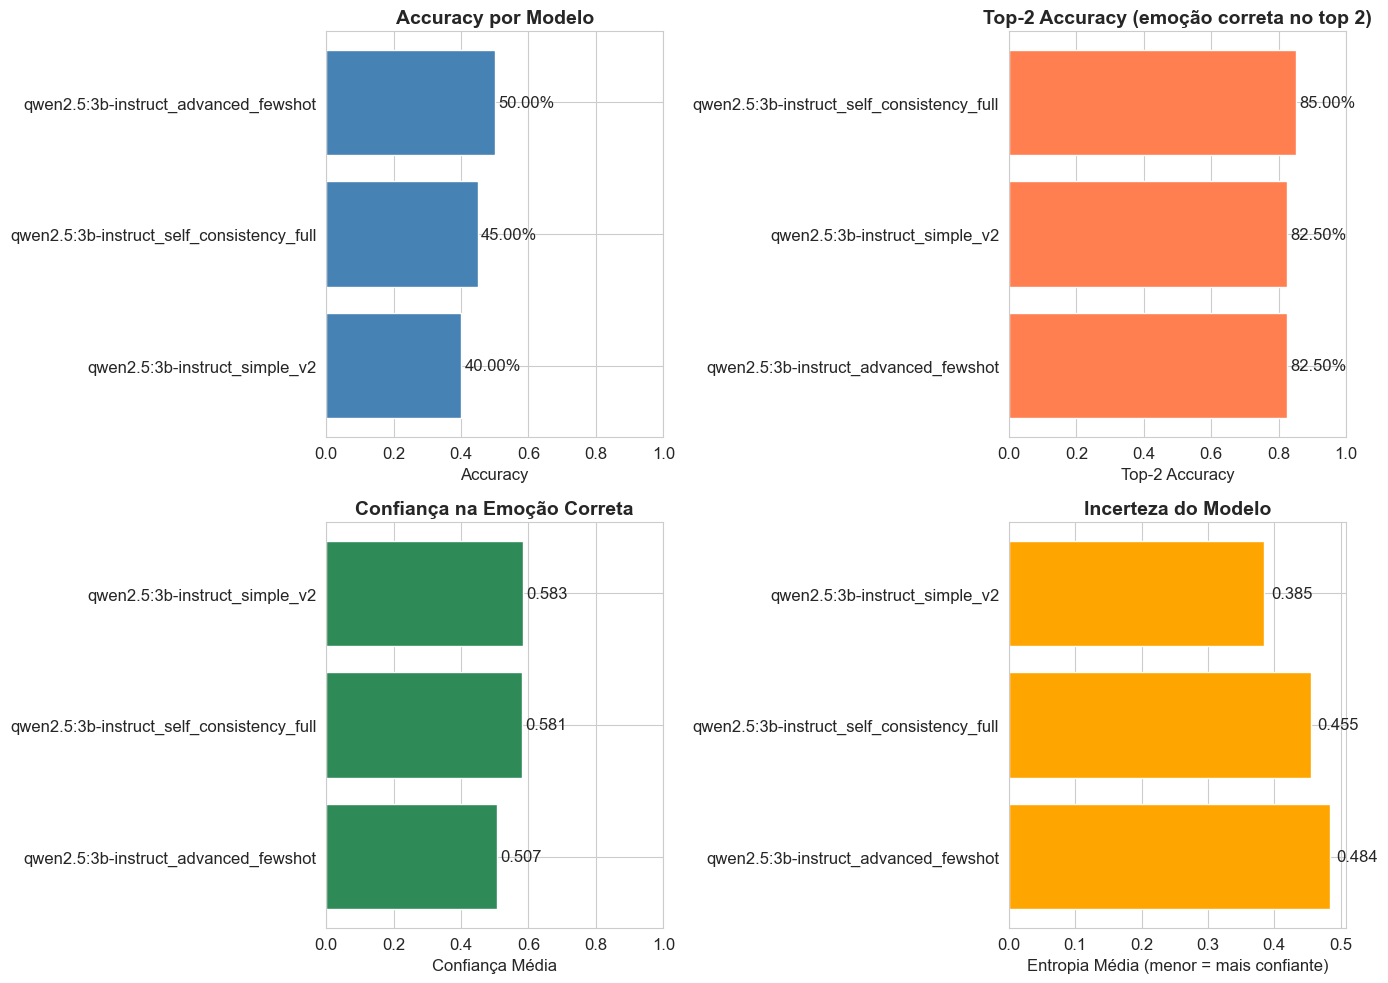

In [9]:
if not df_all.empty:
    # Gráfico comparativo
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Accuracy
    ax1 = axes[0, 0]
    sorted_df = df_summary.sort_values('accuracy', ascending=True)
    bars = ax1.barh(sorted_df['model'], sorted_df['accuracy'], color='steelblue')
    ax1.set_xlabel('Accuracy')
    ax1.set_title('Accuracy por Modelo', fontweight='bold', fontsize=14)
    ax1.set_xlim(0, 1)
    for bar, val in zip(bars, sorted_df['accuracy']):
        ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2%}', va='center')
    
    # Top-2 Accuracy
    ax2 = axes[0, 1]
    sorted_df = df_summary.sort_values('top_2_accuracy', ascending=True)
    bars = ax2.barh(sorted_df['model'], sorted_df['top_2_accuracy'], color='coral')
    ax2.set_xlabel('Top-2 Accuracy')
    ax2.set_title('Top-2 Accuracy (emoção correta no top 2)', fontweight='bold', fontsize=14)
    ax2.set_xlim(0, 1)
    for bar, val in zip(bars, sorted_df['top_2_accuracy']):
        ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2%}', va='center')
    
    # Confiança média
    ax3 = axes[1, 0]
    sorted_df = df_summary.sort_values('mean_confidence_correct', ascending=True)
    bars = ax3.barh(sorted_df['model'], sorted_df['mean_confidence_correct'], color='seagreen')
    ax3.set_xlabel('Confiança Média')
    ax3.set_title('Confiança na Emoção Correta', fontweight='bold', fontsize=14)
    ax3.set_xlim(0, 1)
    for bar, val in zip(bars, sorted_df['mean_confidence_correct']):
        ax3.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
    
    # Entropia
    ax4 = axes[1, 1]
    sorted_df = df_summary.sort_values('mean_entropy', ascending=False)
    colors = ['red' if x > 0.6 else 'orange' if x > 0.3 else 'green' for x in sorted_df['mean_entropy']]
    bars = ax4.barh(sorted_df['model'], sorted_df['mean_entropy'], color=colors)
    ax4.set_xlabel('Entropia Média (menor = mais confiante)')
    ax4.set_title('Incerteza do Modelo', fontweight='bold', fontsize=14)
    for bar, val in zip(bars, sorted_df['mean_entropy']):
        ax4.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
    
    plt.tight_layout()
    plt.show()

🔍 ANÁLISE DETALHADA - Melhor Modelo: qwen2.5:3b-instruct_advanced_fewshot


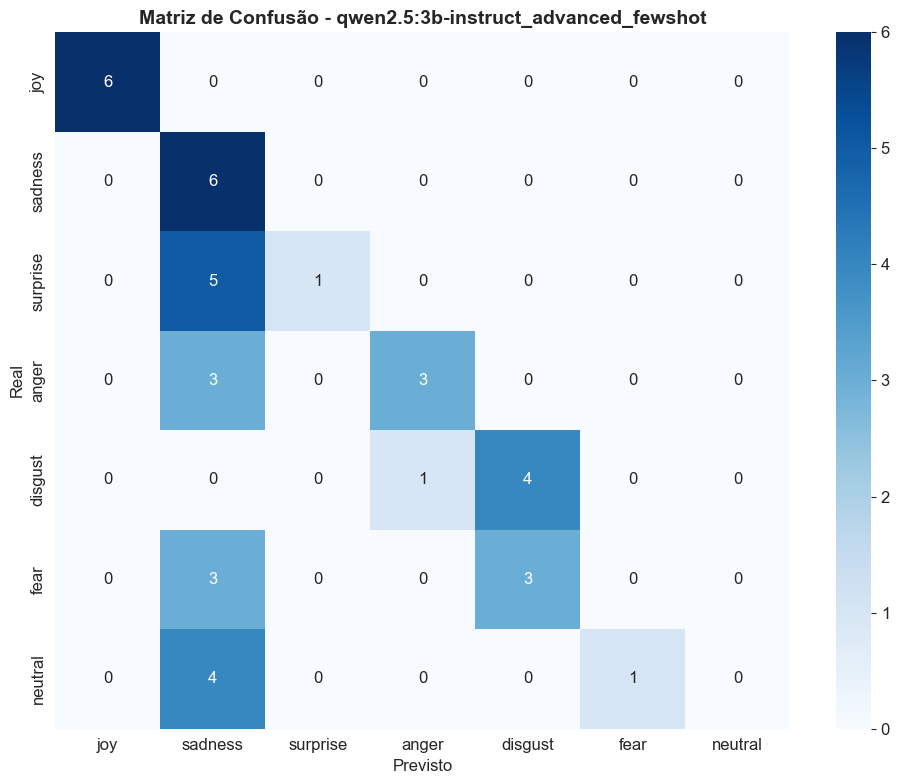


📋 Relatório de Classificação por Emoção:
--------------------------------------------------
  joy         : ████████████████████ 100.0% (6/6) | conf=0.89 | rank=1.0
  sadness     : ████████████████████ 100.0% (6/6) | conf=0.93 | rank=1.0
  surprise    : ███ 16.7% (1/6) | conf=0.13 | rank=2.2
  anger       : ██████████ 50.0% (3/6) | conf=0.43 | rank=1.7
  disgust     : ████████████████ 80.0% (4/5) | conf=0.74 | rank=2.0
  fear        :  0.0% (0/6) | conf=0.26 | rank=2.7
  neutral     :  0.0% (0/5) | conf=0.14 | rank=4.0

❌ Total de erros: 20/40 (50.0%)

📝 Detalhe dos erros:
  • U001: Real=surprise → Previsto=sadness
  • U003: Real=surprise → Previsto=sadness
  • U004: Real=surprise → Previsto=sadness
  • U005: Real=surprise → Previsto=sadness
  • U006: Real=surprise → Previsto=sadness
  • A004: Real=anger → Previsto=sadness
  • A005: Real=anger → Previsto=sadness
  • A006: Real=anger → Previsto=sadness
  • D003: Real=disgust → Previsto=anger
  • F001: Real=fear → Previsto=disgust
  • F

In [10]:
if not df_all.empty:
    # Análise detalhada do melhor modelo
    best_model = df_summary.iloc[0]['model']
    best_results = df_all[df_all['model'] == best_model]
    
    print("=" * 80)
    print(f"🔍 ANÁLISE DETALHADA - Melhor Modelo: {best_model}")
    print("=" * 80)
    
    # Matriz de confusão
    cm = confusion_matrix(best_results['true_label'], best_results['predicted_label'], labels=EMOTIONS)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title(f'Matriz de Confusão - {best_model}', fontsize=14, fontweight='bold')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.tight_layout()
    plt.show()
    
    # Relatório por emoção
    print("\n📋 Relatório de Classificação por Emoção:")
    print("-" * 50)
    for emotion in EMOTIONS:
        emotion_data = best_results[best_results['true_label'] == emotion]
        if len(emotion_data) > 0:
            correct = emotion_data['correct'].sum()
            total = len(emotion_data)
            acc = correct/total
            conf = emotion_data['confidence_correct_label'].mean()
            rank = emotion_data['true_label_rank'].mean()
            
            bar = "█" * int(acc * 20)
            print(f"  {emotion:12s}: {bar} {acc:.1%} ({correct}/{total}) | conf={conf:.2f} | rank={rank:.1f}")
    
    # Erros detalhados
    errors = best_results[~best_results['correct']]
    print(f"\n❌ Total de erros: {len(errors)}/{len(best_results)} ({len(errors)/len(best_results):.1%})")
    
    if len(errors) > 0:
        print("\n📝 Detalhe dos erros:")
        for _, row in errors.iterrows():
            print(f"  • {row['id']}: Real={row['true_label']} → Previsto={row['predicted_label']}")
    
    # Análise de confiança
    print(f"\n📊 Análise de Confiança vs Acerto:")
    high_conf = best_results[best_results['confidence_correct_label'] > 0.7]
    med_conf = best_results[(best_results['confidence_correct_label'] > 0.4) & (best_results['confidence_correct_label'] <= 0.7)]
    low_conf = best_results[best_results['confidence_correct_label'] <= 0.4]
    
    print(f"  Alta confiança (>70%): {high_conf['correct'].mean():.1%} acertos ({len(high_conf)} casos)")
    print(f"  Média confiança (40-70%): {med_conf['correct'].mean():.1%} acertos ({len(med_conf)} casos)")
    print(f"  Baixa confiança (<40%): {low_conf['correct'].mean():.1%} acertos ({len(low_conf)} casos)")

In [11]:
if not df_all.empty:
    # Comparação entre versões
    print("=" * 80)
    print("📈 COMPARAÇÃO ENTRE VERSÕES")
    print("=" * 80)
    
    versions = {
        'simple_v2': 'Simple (temp=0.1)',
        'advanced_fewshot': 'Advanced com Few-Shot',
        'self_consistency_full': 'Self-Consistency (3 amostras)'
    }
    
    for version_key, version_name in versions.items():
        model_data = df_summary[df_summary['model'].str.contains(version_key)]
        if not model_data.empty:
            row = model_data.iloc[0]
            print(f"\n  {version_name}:")
            print(f"    Accuracy: {row['accuracy']:.2%}")
            print(f"    Top-2: {row['top_2_accuracy']:.2%}")
            print(f"    Confiança: {row['mean_confidence_correct']:.3f}")
            print(f"    Entropia: {row['mean_entropy']:.3f}")
    
    # Exportar resultados
    df_all.to_csv('ollama_optimized_results.csv', index=False, encoding='utf-8')
    df_summary.to_csv('ollama_optimized_summary.csv', index=False, encoding='utf-8')
    
    print("\n✅ Resultados salvos:")
    print("   - ollama_optimized_results.csv")
    print("   - ollama_optimized_summary.csv")

print("\n" + "=" * 80)
print("🎯 RECOMENDAÇÃO FINAL")
print("=" * 80)

if not df_all.empty:
    best_model = df_summary.iloc[0]['model']
    best_acc = df_summary.iloc[0]['accuracy']
    
    print(f"\n🏆 Melhor modelo: {best_model}")
    print(f"   Accuracy: {best_acc:.2%}")
    
    if 'self_consistency' in best_model:
        print("\n✅ RECOMENDAÇÃO: Usar Self-Consistency para o produto final")
        print("   • Mais robusto e estável")
        print("   • Melhor precisão geral")
        print("   • Compensa o custo computacional adicional")
    elif 'advanced_fewshot' in best_model:
        print("\n✅ RECOMENDAÇÃO: Usar Advanced com Few-Shot")
        print("   • Excelente para casos ambíguos")
        print("   • Melhor para surprise, fear, disgust")
    else:
        print("\n✅ RECOMENDAÇÃO: Usar versão Simple com temperatura baixa")
        print("   • Mais rápida")
        print("   • Menos recursos")
else:
    print("\n❌ Execute o benchmark primeiro (Ollama precisa estar em execução)")

print("\n" + "=" * 80)
print("✅ Notebook pronto!")
print("=" * 80)

📈 COMPARAÇÃO ENTRE VERSÕES

  Simple (temp=0.1):
    Accuracy: 40.00%
    Top-2: 82.50%
    Confiança: 0.583
    Entropia: 0.385

  Advanced com Few-Shot:
    Accuracy: 50.00%
    Top-2: 82.50%
    Confiança: 0.507
    Entropia: 0.484

  Self-Consistency (3 amostras):
    Accuracy: 45.00%
    Top-2: 85.00%
    Confiança: 0.581
    Entropia: 0.455

✅ Resultados salvos:
   - ollama_optimized_results.csv
   - ollama_optimized_summary.csv

🎯 RECOMENDAÇÃO FINAL

🏆 Melhor modelo: qwen2.5:3b-instruct_advanced_fewshot
   Accuracy: 50.00%

✅ RECOMENDAÇÃO: Usar Advanced com Few-Shot
   • Excelente para casos ambíguos
   • Melhor para surprise, fear, disgust

✅ Notebook pronto!
